Shape: (128, 1710)
Data type: float32
Min: -63.721275329589844, Max: 16.27872657775879
Memory usage: 0.83 MB


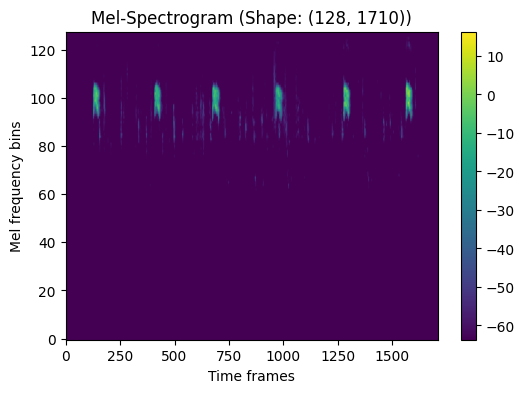

2D 이미지 크기: 1710 × 128 픽셀


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 파일 로드
mel_spec_path = r"C:\Users\orgin\Desktop\XC134896.npy"
mel_spec = np.load(mel_spec_path)

print(f"Shape: {mel_spec.shape}")
print(f"Data type: {mel_spec.dtype}")
print(f"Min: {mel_spec.min()}, Max: {mel_spec.max()}")
print(f"Memory usage: {mel_spec.nbytes / (1024*1024):.2f} MB")

# 데이터 구조 확인
if len(mel_spec.shape) == 3:
    print(f"3D 데이터: {mel_spec.shape[0]} × {mel_spec.shape[1]} × {mel_spec.shape[2]}")
    # 첫 번째 채널만 사용하거나 평균 계산
    mel_spec_2d = mel_spec.mean(axis=2)  # 또는 mel_spec[:, :, 0]
else:
    mel_spec_2d = mel_spec

# 시각화
plt.figure(figsize=(6, 4))
plt.imshow(mel_spec_2d, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar()
plt.title(f'Mel-Spectrogram (Shape: {mel_spec_2d.shape})')
plt.xlabel('Time frames')
plt.ylabel('Mel frequency bins')
plt.show()

print(f"2D 이미지 크기: {mel_spec_2d.shape[1]} × {mel_spec_2d.shape[0]} 픽셀")

In [7]:
import os
from PIL import Image

# 최상위 폴더 경로
root_dir = r"C:\Users\orgin\Desktop\sparrow"

# 이미지 확장자
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}

# 결과 저장
image_info = []

# 모든 하위 폴더 순회
for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if any(file.lower().endswith(ext) for ext in image_extensions):
            file_path = os.path.join(subdir, file)
            try:
                with Image.open(file_path) as img:
                    width, height = img.size
                    folder_name = os.path.basename(subdir)
                    image_info.append({
                        'folder': folder_name,
                        'filename': file,
                        'width': width,
                        'height': height
                    })
            except Exception as e:
                print(f"오류: {file_path} - {e}")

# 전체 이미지 개수
print(f"전체 이미지 개수: {len(image_info)}")

# 각 폴더별 이미지 개수
from collections import Counter
folder_counts = Counter([info['folder'] for info in image_info])
print("\n폴더별 이미지 개수:")
for folder, count in folder_counts.items():
    print(f"{folder}: {count}장")

# 이미지 크기 통계
if image_info:
    widths = [info['width'] for info in image_info]
    heights = [info['height'] for info in image_info]
    print("\n전체 이미지 크기 통계:")
    print(f"가로 최소: {min(widths)} / 최대: {max(widths)} / 평균: {sum(widths)/len(widths):.1f}")
    print(f"세로 최소: {min(heights)} / 최대: {max(heights)} / 평균: {sum(heights)/len(heights):.1f}")

    # 가장 흔한 사이즈 Top 5
    from collections import Counter
    size_counter = Counter([(w, h) for w, h in zip(widths, heights)])
    print("\n가장 흔한 이미지 크기 Top 5:")
    for (w, h), cnt in size_counter.most_common(5):
        print(f"{w}x{h}: {cnt}장")

# 예시로 앞 10개만 출력
print("\n샘플 10개:")
for info in image_info[:10]:
    print(f"{info['folder']}/{info['filename']} - {info['width']}x{info['height']}")

# (선택) pandas로 표로 보기
import pandas as pd
df = pd.DataFrame(image_info)
df.head(10)

전체 이미지 개수: 1244

폴더별 이미지 개수:
113.Baird_Sparrow: 50장
114.Black_throated_Sparrow: 60장
115.Brewer_Sparrow: 59장
116.Chipping_Sparrow: 60장
117.Clay_colored_Sparrow: 59장
118.House_Sparrow: 60장
119.Field_Sparrow: 59장
120.Fox_Sparrow: 60장
121.Grasshopper_Sparrow: 60장
122.Harris_Sparrow: 60장
123.Henslow_Sparrow: 60장
124.Le_Conte_Sparrow: 59장
125.Lincoln_Sparrow: 59장
126.Nelson_Sharp_tailed_Sparrow: 59장
127.Savannah_Sparrow: 60장
128.Seaside_Sparrow: 60장
129.Song_Sparrow: 60장
130.Tree_Sparrow: 60장
131.Vesper_Sparrow: 60장
132.White_crowned_Sparrow: 60장
133.White_throated_Sparrow: 60장

전체 이미지 크기 통계:
가로 최소: 140 / 최대: 500 / 평균: 466.2
세로 최소: 134 / 최대: 500 / 평균: 389.7

가장 흔한 이미지 크기 Top 5:
500x333: 188장
500x375: 115장
500x334: 49장
500x400: 42장
333x500: 38장

샘플 10개:
113.Baird_Sparrow/Baird_Sparrow_0001_794578.jpg - 500x375
113.Baird_Sparrow/Baird_Sparrow_0002_794551.jpg - 300x300
113.Baird_Sparrow/Baird_Sparrow_0003_794558.jpg - 500x333
113.Baird_Sparrow/Baird_Sparrow_0004_794568.jpg - 334x500
113.Baird_S

,folder,filename,width,height
0,113.Baird_Sparrow,Baird_Sparrow_0001_794578.jpg,500,375
1,113.Baird_Sparrow,Baird_Sparrow_0002_794551.jpg,300,300
2,113.Baird_Sparrow,Baird_Sparrow_0003_794558.jpg,500,333
3,113.Baird_Sparrow,Baird_Sparrow_0004_794568.jpg,334,500
4,113.Baird_Sparrow,Baird_Sparrow_0005_794565.jpg,334,500
5,113.Baird_Sparrow,Baird_Sparrow_0006_794579.jpg,500,343
6,113.Baird_Sparrow,Baird_Sparrow_0007_794563.jpg,500,375
7,113.Baird_Sparrow,Baird_Sparrow_0008_106929.jpg,500,349
8,113.Baird_Sparrow,Baird_Sparrow_0009_106882.jpg,500,400
9,113.Baird_Sparrow,Baird_Sparrow_0010_794575.jpg,500,365


In [16]:
import os
import shutil

src_root = './data/bird_img'
dst_root = r'C:\Users\orgin\Desktop\spwar'

for category in ['sparrow', 'warbler']:
    src_category_path = os.path.join(src_root, category)
    dst_category_path = os.path.join(dst_root, category)
    os.makedirs(dst_category_path, exist_ok=True)

    # 하위 폴더(예: 1, 2, ...) 순회
    for subfolder in os.listdir(src_category_path):
        subfolder_path = os.path.join(src_category_path, subfolder)
        if not os.path.isdir(subfolder_path):
            continue

        # 하위 폴더 안의 모든 파일 복사
        for fname in os.listdir(subfolder_path):
            src_file = os.path.join(subfolder_path, fname)
            dst_file = os.path.join(dst_category_path, fname)
            if not os.path.isfile(src_file):
                continue
            if not os.path.exists(dst_file):
                shutil.copy2(src_file, dst_file)

print("복사가 완료되었습니다. (중복 파일은 생략됨)")

복사가 완료되었습니다. (중복 파일은 생략됨)


In [ ]:
side_type = ["left", "right"]
jig_index = 1200 #위 블록의 Y축 값 기준으로 선택 부탁드립니다.
jig_line = zmap[:,jig_index-5:jig_index+5]
print(jig_line.shape)
jig_zvalue = np.median(jig_line)
print(zmap.min(),zmap.max())
print(jig_line.min(),jig_line.max())
print(jig_zvalue.shape)
print(jig_zvalue)
preview_image, edge_original_from_correct, edge_filtered, edge_corrected, corrected_zmap = vibration_correction(
    zmap, 
    initial_margin=10, 
    final_margin=0, 
    radius_roi=0.9,
    z_init=jig_zvalue, # 중앙값 대표 진동보정함수의 기준면으로 들어감
    side=side_type[1], #right
    convert_nan=False,
    skip_preview=False,
    method='emd', # or 'fft'
    angle_per_pixel=0.1,
    expected_period_degrees=4000.0,
    fit_amplitude=True,
    fit_phase=True,
    # visual_range=(1300,1500)
)

print(edge_corrected.mean(), edge_corrected.std())
plt.figure(figsize=(10, 10), dpi=600)
plt.imshow(preview_image)
plt.axis('off')
plt.show()
print(corrected_zmap.shape)

(10000, 10)
0 34866
0 32888
()
32865.0
✅ 캐시된 파일 로드


NameError: name 'emd' is not defined

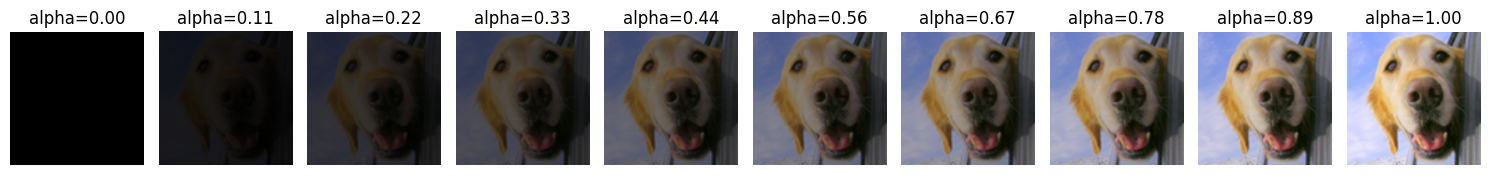

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. 이미지 로드 (예시: 224x224 RGB 이미지)
img_path = "C:/Users/orgin/Desktop/ForTest/stl10_test/test_image_png_27.png"  # 이미지 경로를 지정하세요
img = Image.open(img_path).convert('RGB').resize((224, 224))
img_np = np.array(img) / 255.0  # 0~1로 정규화
input_tensor = torch.tensor(img_np, dtype=torch.float32).permute(2, 0, 1)  # (C, H, W)

# 2. baseline (검은색 이미지 생성)
baseline = torch.zeros_like(input_tensor)

# 3. step 개수 m 지정해서 보간한 m개의 이미지 생성
m = 10  # 원하는 step 개수
alphas = torch.linspace(0, 1, m)
interpolated_imgs = []
for alpha in alphas:
    interpolated = baseline + alpha * (input_tensor - baseline)
    interpolated_imgs.append(interpolated)

# 4. 모두 plot
plt.figure(figsize=(15, 3))
for i, img_t in enumerate(interpolated_imgs):
    plt.subplot(1, m, i+1)
    img_show = img_t.permute(1, 2, 0).numpy()  # (H, W, C)
    plt.imshow(np.clip(img_show, 0, 1))
    plt.axis('off')
    plt.title(f'alpha={alphas[i]:.2f}')
plt.tight_layout()
plt.show()

In [ ]:
side_type = ["left", "right"]
jig_index = 1200 #위 블록의 Y축 값 기준으로 선택 부탁드립니다.
jig_line = zmap[:,jig_index-5:jig_index+5]
print(jig_line.shape)
jig_zvalue = np.median(jig_line)
print(zmap.min(),zmap.max())
print(jig_line.min(),jig_line.max())
print(jig_zvalue.shape)
print(jig_zvalue)
preview_image, edge_original_from_correct, edge_filtered, edge_corrected, corrected_zmap = vibration_correction(
    zmap, 
    initial_margin=10, 
    final_margin=0, 
    radius_roi=0.9,
    z_init=jig_zvalue, # 중앙값 대표 진동보정함수의 기준면으로 들어감
    side=side_type[1], #right
    convert_nan=False,
    skip_preview=False,
    method='emd', # or 'fft'
    angle_per_pixel=0.1,
    expected_period_degrees=4000.0,
    fit_amplitude=True,
    fit_phase=True,
    # visual_range=(1300,1500)
)

print(edge_corrected.mean(), edge_corrected.std())
plt.figure(figsize=(10, 10), dpi=600)
plt.imshow(preview_image)
plt.axis('off')
plt.show()
print(corrected_zmap.shape)

(10000, 10)
0 34866
0 32888
()
32865.0
✅ 캐시된 파일 로드


NameError: name 'emd' is not defined

In [ ]:
side_type = ["left", "right"]
jig_index = 1200 #위 블록의 Y축 값 기준으로 선택 부탁드립니다.
jig_line = zmap[:,jig_index-5:jig_index+5]
print(jig_line.shape)
jig_zvalue = np.median(jig_line)
print(zmap.min(),zmap.max())
print(jig_line.min(),jig_line.max())
print(jig_zvalue.shape)
print(jig_zvalue)
preview_image, edge_original_from_correct, edge_filtered, edge_corrected, corrected_zmap = vibration_correction(
    zmap, 
    initial_margin=10, 
    final_margin=0, 
    radius_roi=0.9,
    z_init=jig_zvalue, # 중앙값 대표 진동보정함수의 기준면으로 들어감
    side=side_type[1], #right
    convert_nan=False,
    skip_preview=False,
    method='emd', # or 'fft'
    angle_per_pixel=0.1,
    expected_period_degrees=4000.0,
    fit_amplitude=True,
    fit_phase=True,
    # visual_range=(1300,1500)
)

print(edge_corrected.mean(), edge_corrected.std())
plt.figure(figsize=(10, 10), dpi=600)
plt.imshow(preview_image)
plt.axis('off')
plt.show()
print(corrected_zmap.shape)

(10000, 10)
0 34866
0 32888
()
32865.0
✅ 캐시된 파일 로드


NameError: name 'emd' is not defined

In [ ]:
side_type = ["left", "right"]
jig_index = 1200 #위 블록의 Y축 값 기준으로 선택 부탁드립니다.
jig_line = zmap[:,jig_index-5:jig_index+5]
print(jig_line.shape)
jig_zvalue = np.median(jig_line)
print(zmap.min(),zmap.max())
print(jig_line.min(),jig_line.max())
print(jig_zvalue.shape)
print(jig_zvalue)
preview_image, edge_original_from_correct, edge_filtered, edge_corrected, corrected_zmap = vibration_correction(
    zmap, 
    initial_margin=10, 
    final_margin=0, 
    radius_roi=0.9,
    z_init=jig_zvalue, # 중앙값 대표 진동보정함수의 기준면으로 들어감
    side=side_type[1], #right
    convert_nan=False,
    skip_preview=False,
    method='emd', # or 'fft'
    angle_per_pixel=0.1,
    expected_period_degrees=4000.0,
    fit_amplitude=True,
    fit_phase=True,
    # visual_range=(1300,1500)
)

print(edge_corrected.mean(), edge_corrected.std())
plt.figure(figsize=(10, 10), dpi=600)
plt.imshow(preview_image)
plt.axis('off')
plt.show()
print(corrected_zmap.shape)

(10000, 10)
0 34866
0 32888
()
32865.0
✅ 캐시된 파일 로드


NameError: name 'emd' is not defined